In [18]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.stochastic_sir import run_stochastic_sir
from src.deterministic_sir import run_deterministic_sir
from src.ml_model import SIRNet

In [21]:
t, S, I, R = run_stochastic_sir(
    beta=0.3,
    gamma=0.1,
    N=1000,
    I0=10,
    t_max=160,
    dt=1,
    num_runs=50,
    save_results=True,
    random_seed=42
)

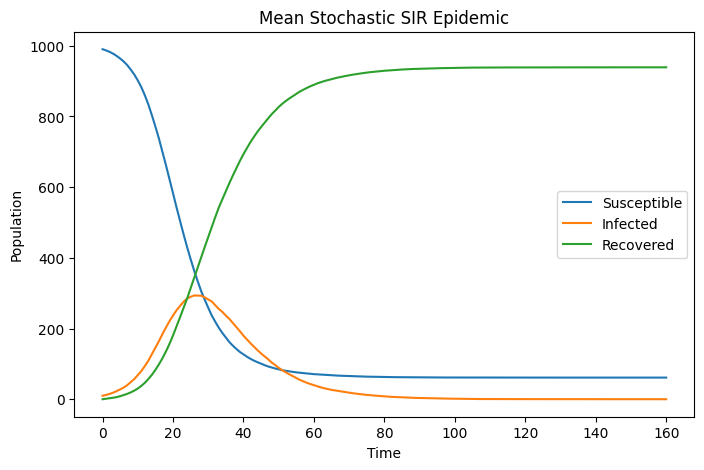

In [22]:
plt.figure(figsize=(8,5))

plt.plot(t, S, label="Susceptible")
plt.plot(t, I, label="Infected")
plt.plot(t, R, label="Recovered")

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Mean Stochastic SIR Epidemic")

plt.legend()
plt.show()

In [24]:
t_d, S_d, I_d, R_d = run_deterministic_sir(
    beta=0.3,
    gamma=0.1,
    N=1000,
    I0=10,
    t_max=160
)

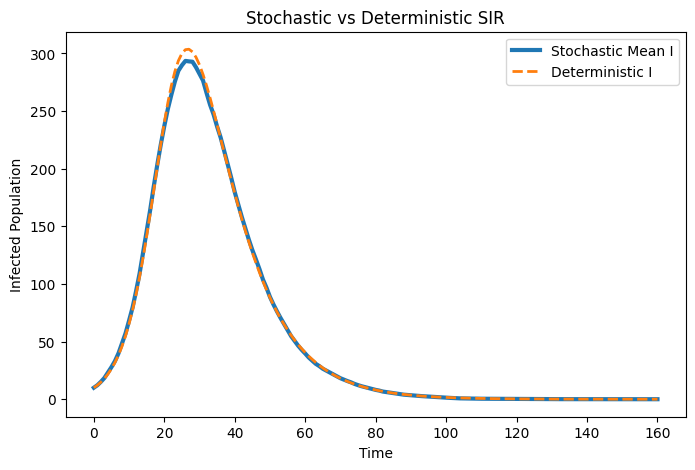

In [25]:
plt.figure(figsize=(8,5))

plt.plot(t, I, label="Stochastic Mean I", linewidth=3)
plt.plot(t_d, I_d, "--", label="Deterministic I", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title("Stochastic vs Deterministic SIR")

plt.legend()
plt.show()

In [27]:
model = SIRNet()
model.load_state_dict(torch.load("../results/sir_nn_model.pt"))
model.eval()

SIRNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=3, bias=True)
    (7): Sigmoid()
  )
)

In [28]:
t_norm = t / t.max()

t_tensor = torch.tensor(t_norm, dtype=torch.float32).view(-1,1)

pred = model(t_tensor).detach().numpy()

N = 1000

S_pred = pred[:,0] * N
I_pred = pred[:,1] * N
R_pred = pred[:,2] * N

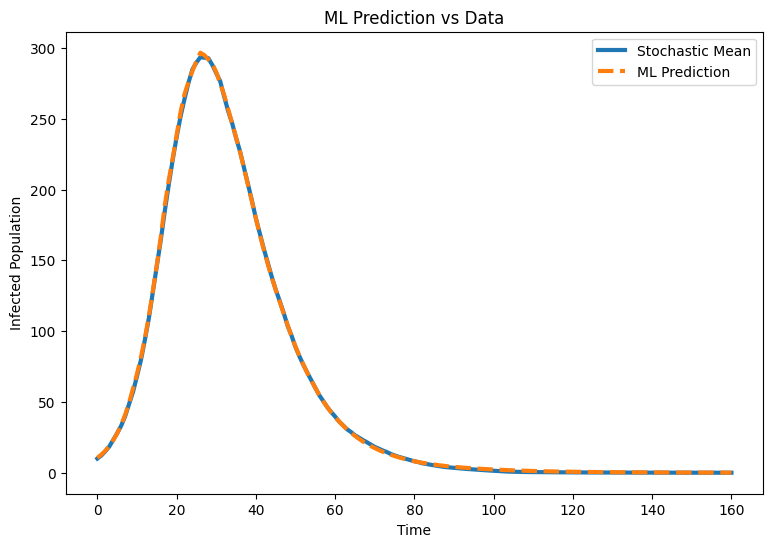

In [29]:
plt.figure(figsize=(9,6))

plt.plot(t, I, label="Stochastic Mean", linewidth=3)
plt.plot(t, I_pred, "--", label="ML Prediction", linewidth=3)

plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title("ML Prediction vs Data")

plt.legend()
plt.show()

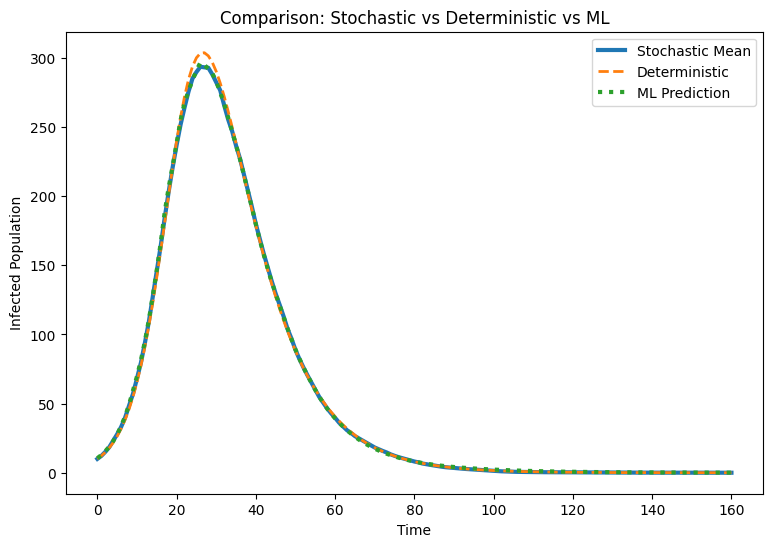

In [30]:
plt.figure(figsize=(9,6))

plt.plot(t, I, label="Stochastic Mean", linewidth=3)
plt.plot(t_d, I_d, "--", label="Deterministic", linewidth=2)
plt.plot(t, I_pred, ":", label="ML Prediction", linewidth=3)

plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title("Comparison: Stochastic vs Deterministic vs ML")

plt.legend()
plt.show()